# ClimaCredit Q – v6

**Ränta = Euribor + bankens marginal + klimatpåslag**

Klimatpåslaget har två delar:
1. **Lånets egen klimatrisk:** högre förväntad förlust när branschens PD stiger i ett EU-klimatscenario och i ett dåligt skördeår.
2. **Kapital:** kostnaden för det extra kapital lånet kräver i den lokala bankens låneportfölj (expected shortfall 99,9 %).

**Nytt i v6** (efter granskningen av v5 och kvantmodell-notebooken):

| | v5 | v6 |
|---|---|---|
| Bankens lånemix | antal företag | landskapets **företagsskulder** (från kvantmodell-notebooken) |
| PD bygg/handel | konkursfrekvens | konkurser **+ saneringar**, kalibrerat till EU-snittet 2,4 % |
| Fysisk klimatrisk | 8 översvämningsområden | alla **18** + **bra/dåliga skördeår** + torkkänslighet |
| Omställning | samma för alla branscher | branschvis (energikrisen 2022) |
| Underbransch | – | TOL 3 siffror, krympt mot branschen |
| Kalkylator | – | justerbar marginal, Euribor 1/3/6/12 mån, löptid, betalningsplan |

Kör cellerna uppifrån och ned. Alla filer ska ligga i samma mapp som notebooken. Graferna sparas som PNG (för pitchen).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from climacredit_model import Model, load_params, firm_shares, payment_plan, SECTORS, NUTS2, NUTS2_NAMES

m = Model()
LAND, STAD = "MK14 South Ostrobothnia", "MK01 Uusimaa"
namn = lambda r: r.split(" ", 1)[1]
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
GREEN, NAVY, GREY, ORANGE, RED = "#1F7A4D", "#0B1F33", "#9AA5B1", "#E8833A", "#C0392B"
print(len(m.regions), "landskap inlästa")

19 landskap inlästa


## 1. Antagandena

Allt som är ett antagande står i `parametrar.json`, med källa. Ändra där, så följer notebooken, kvantmodellen och servern med.

In [2]:
with open("parametrar.json", encoding="utf-8") as f:
    raw = json.load(f)
pd.DataFrame([{"Parameter": k, "Värde": json.dumps(v["value"], ensure_ascii=False)[:80], "Källa": v["source"]}
              for k, v in raw.items() if not k.startswith("_")]).set_index("Parameter")

,Värde,Källa
Parameter,,
bank_size_meur,300,Assumption: corporate loan book of a typical local OP cooperative bank (a few hundred ...
lgd,0.45,Basel foundation IRB LGD for senior unsecured corporate exposures.
rho_economy,"{""Agriculture"": 0.15, ""Construction"": 0.15, ""Trade"": 0.15}",Basel corporate asset correlation range 0.12-0.24. Finnish bankruptcy data alone give ...
rho_climate,"{""Agriculture"": 0.1, ""Construction"": 0.08, ""Trade"": 0.02}",Assumption: agriculture and construction are the most climate-sensitive sectors (ECB 2...
flood_rho_add,"{""Agriculture"": 0.05, ""Construction"": 0.03, ""Trade"": 0.0}",Assumption: extra climate sensitivity in regions with a significant RIVER flood risk a...
coastal_flood_rho_add,"{""Agriculture"": 0.0, ""Construction"": 0.03, ""Trade"": 0.01}",Assumption: extra climate sensitivity in regions with a significant COASTAL (sea) floo...
flood_areas,"{""MK01 Uusimaa"": [{""name"": ""Helsinki-Espoo coast"", ""type"": ""coastal""}], ""MK02 So","The 18 significant flood risk areas 2025-2030 (14 river, 4 coastal), Ministry of Agric..."
pd_agriculture_national,0.035,"Starting PD of EU banks' agricultural loans, ECB/ESAs Fit-for-55 climate scenario anal..."
pd_construction_trade_average,0.024,"Average PD of EU banks' corporate loans, ECB/ESAs Fit-for-55 (Nov 2024). The average o..."


## 2. De lokala bankernas låneportfölj: skulder i stället för antal företag

Varje bank har 300 M€ i företagslån. I v5 fördelade vi dem efter **antal företag**, men en gård har mycket mindre lån
än ett byggföretag, så jordbruket blev för stort överallt (Nyland 23 %).

I v6 följer fördelningen landskapets **företagsskulder** (idén kommer från kvantmodell-notebooken):
- **jordbruk:** antal gårdar × skuld per gård (Statistikcentralen 141b, 13z5)
- **bygg och handel:** små och medelstora företags räntekostnader (13w2), fördelade efter landskapets andel av branschens produktion (13x2)

Åland saknar dessa data och får företagsmixen omräknad med rikets skuld per företag.

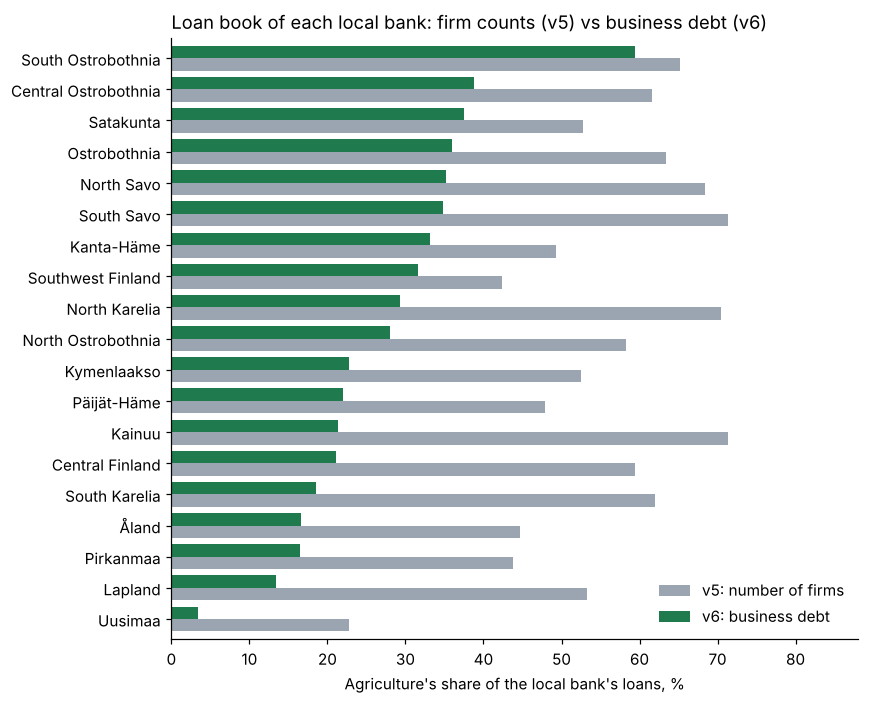

,Jordbruk v5 (antal företag) %,Jordbruk v6 (skulder) %,Bygg v6 %,Handel v6 %
South Ostrobothnia,65.200,59.400,19.600,21.000
Central Ostrobothnia,61.600,38.800,28.200,33.000
Satakunta,52.700,37.500,34.600,27.900
Ostrobothnia,63.400,36.000,41.200,22.800
North Savo,68.300,35.200,30.600,34.100
South Savo,71.300,34.900,28.800,36.300
Kanta-Häme,49.300,33.200,25.700,41.100
Southwest Finland,42.400,31.600,32.300,36.000
North Karelia,70.400,29.300,31.500,39.200
North Ostrobothnia,58.300,28.000,41.500,30.500


In [3]:
old = firm_shares(m.data).loc[m.regions, "Agriculture"]
mix = pd.DataFrame({"Jordbruk v5 (antal företag) %": old * 100,
                    "Jordbruk v6 (skulder) %": m.shares["Agriculture"] * 100,
                    "Bygg v6 %": m.shares["Construction"] * 100,
                    "Handel v6 %": m.shares["Trade"] * 100})
mix.index = [namn(r) for r in mix.index]
mix = mix.sort_values("Jordbruk v6 (skulder) %")
ax = mix[["Jordbruk v5 (antal företag) %", "Jordbruk v6 (skulder) %"]].plot.barh(figsize=(8, 6.5), color=[GREY, GREEN], width=0.8)
ax.set_xlabel("Agriculture's share of the local bank's loans, %")
ax.set_title("Loan book of each local bank: firm counts (v5) vs business debt (v6)", loc="left")
ax.legend(["v5: number of firms", "v6: business debt"], frameon=False, loc="lower right")
ax.set_xlim(0, 88); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("graf_lanemix.png", dpi=200); plt.show()
mix.sort_values("Jordbruk v6 (skulder) %", ascending=False).round(1)

## 3. Sannolikhet för fallissemang (PD) idag

- **Jordbruk:** EU-bankernas jordbrukslån har PD 3,5 % (ECB/ESAs Fit-for-55). Finska gårdskonkurser (~0,08 % per år)
  är alldeles för sällsynta för att mäta bankfallissemang: gårdar läggs ner eller saneras i stället för att gå i konkurs.
- **Bygg och handel:** finska fallissemang = konkurser **+ företagssaneringar** 2018–2024. Nivån skalas så att snittet för bygg
  och handel blir EU-snittet 2,4 %. Det kallas *kalibrering till central tendens* och är så banker kalibrerar sina ratingmodeller:
  ordningen kommer från datan, nivån från ett långsiktigt snitt.
- **Landskap:** landskapets egen konkursfrekvens får vikten n/(n+100), där n = antal konkurser 2018–2024 (credibility-vikt).
  Små landskap dras mot riket, så slumpen i några få konkurser styr inte räntan.

In [4]:
nd = pd.DataFrame(m.national_defaults).T
nd["bankruptcy_rate"] *= 100
nd["default_rate"] *= 100
nd["PD i modellen %"] = [m.pd_level[s] * 100 for s in nd.index]
nd.columns = ["Konkurser 2018–24", "Saneringar 2018–24", "Företagsår", "Konkursfrekvens %", "Konkurs + sanering %", "PD i modellen %"]
print(f"Skala från finska fallissemang till bank-PD: {m.pd_calibration_scale:.2f}  (bygg + handel i snitt = EU:s 2,4 %)")
print(f"Jordbruk: EU-bankernas PD {m.pd_level['Agriculture']*100:.1f} %")
nd.round(3)

Skala från finska fallissemang till bank-PD: 2.25  (bygg + handel i snitt = EU:s 2,4 %)
Jordbruk: EU-bankernas PD 3.5 %


,Konkurser 2018–24,Saneringar 2018–24,Företagsår,Konkursfrekvens %,Konkurs + sanering %,PD i modellen %
Construction,"4,060.000",589.000,"381,613.000",1.064,1.218,2.743
Trade,"3,308.000",383.000,"390,410.000",0.847,0.945,2.129


In [5]:
n = m.bankruptcy_counts.loc[m.regions]
z = m.p["regional_weight"] * n / (n + m.p["credibility_k"])
tab = pd.DataFrame({"PD jordbruk %": m.pd_today.loc[m.regions, "Agriculture"] * 100,
                    "PD bygg %": m.pd_today.loc[m.regions, "Construction"] * 100,
                    "PD handel %": m.pd_today.loc[m.regions, "Trade"] * 100,
                    "Gårdskonkurser 2018–24": n["Agriculture"],
                    "Vikt egna data (jordbruk)": z["Agriculture"],
                    "Vikt egna data (bygg)": z["Construction"]})
tab.index = [namn(r) for r in tab.index]
tab.sort_values("PD jordbruk %", ascending=False).round(2)

,PD jordbruk %,PD bygg %,PD handel %,Gårdskonkurser 2018–24,Vikt egna data (jordbruk),Vikt egna data (bygg)
North Ostrobothnia,4.650,2.500,2.000,75,0.430,0.680
Central Ostrobothnia,4.480,2.510,1.970,25,0.200,0.240
Ostrobothnia,4.330,2.300,1.920,50,0.330,0.450
Kainuu,3.970,2.630,2.390,21,0.170,0.250
South Ostrobothnia,3.950,2.450,2.020,55,0.350,0.590
Lapland,3.680,2.490,1.990,22,0.180,0.520
Satakunta,3.580,2.620,1.980,27,0.210,0.630
North Savo,3.550,2.540,2.180,40,0.290,0.550
North Karelia,3.500,2.850,2.150,26,0.210,0.500
Southwest Finland,3.480,2.480,2.100,37,0.270,0.790


## 4. Omställningsscenarierna (EU Fit-for-55)

ECB/ESAs scenarier till 2030: företagens snitt-PD stiger från 2,4 % med +0,6 / +1,3 / +2,3 procentenheter
(× 1,25 / 1,54 / 1,96). Det är ett **snitt över alla branscher**.

Hur fördelas chocken mellan branscherna? Kvantmodell-notebookens idé: **energikrisen 2022** är Finlands närmaste motsvarighet till
dyr energi, bränsle och gödsel. Från 2018–19 till 2023–24 steg gårdskonkurserna 31 % mer än hela ekonomins, byggets 16 % mer
och handelns inte alls. Men krisen sammanföll med räntehöjningar och en bostadskris, så vi använder mönstret **till hälften**
(`transition_sector_tilt` = 0,5). Vikterna är satta så att snittet över bankernas lån fortfarande är EU:s siffra.

**Hur stressen läggs på:** för branschens genomsnittsföretag är PD = PD idag × multiplikatorn. Tekniskt görs det som en
förskjutning på probit-skalan, vilket i Vasicek-modellen är exakt en förskjutning av den gemensamma faktorn. Fördelen:
ett redan riskabelt företag (t.ex. svaga nyckeltal + dåligt år) stiger mindre i procent, så staplade stressar exploderar inte.

In [6]:
tr = pd.DataFrame({s: m.transition_multiplier(s) for s in m.p["scenarios"]}, index=SECTORS).T
tr.insert(0, "EU-snitt", pd.Series(m.p["scenarios"]))
print("Energikrisen (konkursökning jämfört med hela ekonomin):", {s: round(v, 2) for s, v in m.transition_pattern.items()})
print("Vikt per bransch:", dict(zip(SECTORS, m.transition_weight.round(2))))
tr.round(2)

Energikrisen (konkursökning jämfört med hela ekonomin): {'Agriculture': 1.31, 'Construction': 1.16, 'Trade': 1.0}
Vikt per bransch: {'Agriculture': np.float64(1.8), 'Construction': np.float64(1.18), 'Trade': np.float64(0.5)}


,EU-snitt,Agriculture,Construction,Trade
Today,1.000,1.000,1.000,1.000
Fit-for-55 baseline,1.250,1.450,1.290,1.120
Run-on-brown,1.540,1.970,1.640,1.270
Adverse,1.960,2.730,2.130,1.480


**Kontroll med utsläppsdata:** jordbruket släpper ut ungefär 40 gånger mer växthusgaser per omsatt euro än bygget och
500 gånger mer än handeln. Ett pris på 100 €/ton skulle motsvara över 10 % av jordbrukets omsättning, om det gällde alla utsläpp
(i dag ligger jordbrukets utsläpp mest utanför EU:s utsläppshandel). Det stöder att jordbruket får den största omställningschocken.

In [7]:
ut = pd.read_csv("utslapp_11ig.csv")
oms = pd.read_csv("omsattning_2022.csv", index_col=0)
codes = ["01_jordbruk", "F_bygg", "G_handel"]
e22 = ut[ut.ar == 2022].set_index("bransch")["vaxthusgaser_co2ekv_ton"]
inten = pd.DataFrame({"Växthusgaser 2022 (t CO2e)": e22[codes].values,
                      "Omsättning 2022 (M€)": oms.loc[codes, "omsattning_Me"].values}, index=SECTORS)
inten["t CO2e per M€"] = inten.iloc[:, 0] / inten.iloc[:, 1]
inten["Kostnad vid 100 €/t, % av omsättningen"] = inten["t CO2e per M€"] * 100 / 1e6 * 100
inten.round(2)

,Växthusgaser 2022 (t CO2e),Omsättning 2022 (M€),t CO2e per M€,"Kostnad vid 100 €/t, % av omsättningen"
Agriculture,7342902,"5,822.000","1,261.230",12.610
Construction,1435587,"45,942.320",31.250,0.310
Trade,356618,"145,118.540",2.460,0.020


## 5. Fysisk klimatrisk: bra och dåliga år

v5 hade bara översvämning. v6 lägger till **väderår** och **torka**, med Eurostats spannmålsskörd per landsdel (NUTS 2), 2010–2024:

1. **Skördeavvikelse:** hur mycket skörden per hektar avvek från landsdelens egen trend ett visst år.
2. **Analogiår:** *Bra år* = 2019 (bästa skörden mot trenden), *Dåligt år* = 2018 (torka; gårdarnas företagarinkomst föll nästan 40 %, Luke),
   *Mycket dåligt år* = 2021 (het och torr sommar; minsta spannmålsskörden sedan 1992, Luke).
3. **Gårdarnas PD i ett väderår** = PD × exp(−1,5 × skördeavvikelsen). En skörd 25 % under trenden ger ungefär 1,5 × fler fallissemang.
   1,5 är illustrativt: 2021 och 2018 pekar på 1,7–1,9, men länken är statistiskt svag (se avsnitt 12).
4. **Torkkänslighet:** landsdelar där skörden svänger mer får högre klimatkänslighet för jordbrukslån (till hälften av skillnaden).
5. **Översvämning:** alla 18 betydande översvämningsområden 2025–2030 (14 älv, 4 kust). Älv påverkar jordbruk och bygg, kust bygg och handel.

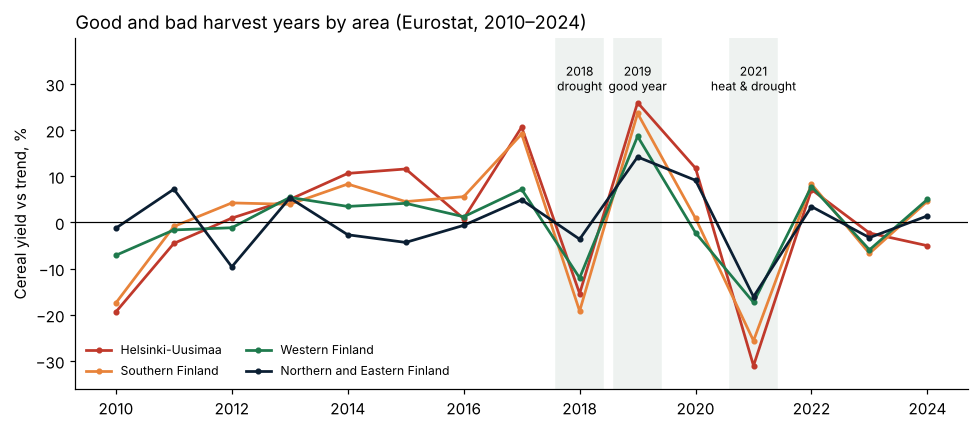

In [8]:
a = np.expm1(m.anomaly) * 100
fig, ax = plt.subplots(figsize=(9, 4))
for c, col in {"FI1B": RED, "FI1C": ORANGE, "FI19": GREEN, "FI1D": NAVY}.items():
    ax.plot(a.index, a[c], marker="o", ms=3, lw=1.8, color=col, label=NUTS2_NAMES[c])
ax.axhline(0, color="black", lw=0.8)
top = a.max().max()
for y, lbl in [(2018, "2018\ndrought"), (2019, "2019\ngood year"), (2021, "2021\nheat & drought")]:
    ax.axvspan(y - 0.4, y + 0.4, color="#EEF2F0", zorder=0)
    ax.text(y, top + 2, lbl, ha="center", va="bottom", fontsize=8)
ax.set_ylim(a.min().min() - 5, top + 14)
ax.set_ylabel("Cereal yield vs trend, %")
ax.set_title("Good and bad harvest years by area (Eurostat, 2010–2024)", loc="left")
ax.legend(frameon=False, ncol=2, fontsize=8, loc="lower left")
plt.tight_layout(); plt.savefig("graf_skordear.png", dpi=200); plt.show()

In [9]:
rows = []
for c in ["FI1B", "FI1C", "FI19", "FI1D", "FI"]:
    row = {"Område": NUTS2_NAMES[c], "Svängning (std) %": m.harvest_sigma[c] * 100}
    for lbl, y in m.p["weather_years"].items():
        if y is not None:
            row[f"{y} skörd %"] = np.expm1(m.anomaly.loc[y, c]) * 100
            row[f"{y} PD-faktor"] = np.exp(-m.p["weather_beta"] * m.anomaly.loc[y, c])
    rows.append(row)
pd.DataFrame(rows).set_index("Område").round(2)

,Svängning (std) %,2019 skörd %,2019 PD-faktor,2018 skörd %,2018 PD-faktor,2021 skörd %,2021 PD-faktor
Område,,,,,,,
Helsinki-Uusimaa,16.350,25.930,0.710,-15.380,1.280,-31.010,1.740
Southern Finland,14.490,23.600,0.730,-19.180,1.380,-25.600,1.560
Western Finland,9.210,18.640,0.770,-12.000,1.210,-17.310,1.330
Northern and Eastern Finland,7.970,14.170,0.820,-3.620,1.060,-16.070,1.300
Whole country,11.020,20.600,0.760,-13.790,1.250,-21.180,1.430


In [10]:
rows = []
for r in m.regions:
    rm, rk = m.rho(r)
    areas = m.p["flood_areas"].get(r, [])
    rows.append({"Landskap": namn(r), "Skördeområde": NUTS2_NAMES[NUTS2[m.code[r]]],
                 "Torkkänslighet": m.drought_scale[r],
                 "Översvämningsområden": ", ".join(f"{x['name']} ({x['type']})" for x in areas) or "–",
                 "Klimatkänslighet jordbruk": rk[0], "bygg": rk[1], "handel": rk[2]})
print("Antal översvämningsområden:", sum(len(v) for v in m.p["flood_areas"].values()))
pd.DataFrame(rows).set_index("Landskap").round(3)

Antal översvämningsområden: 18


,Skördeområde,Torkkänslighet,Översvämningsområden,Klimatkänslighet jordbruk,bygg,handel
Landskap,,,,,,
Uusimaa,Helsinki-Uusimaa,1.586,Helsinki-Espoo coast (coastal),0.159,0.110,0.030
Southwest Finland,Southern Finland,1.353,Turku coast (coastal),0.135,0.110,0.030
Satakunta,Western Finland,0.845,"Pori (Kokemäenjoki) (river), Huittinen (Kokemäenjoki-Loimijoki) (river)",0.134,0.110,0.020
Kanta-Häme,Southern Finland,1.353,–,0.135,0.080,0.020
Pirkanmaa,Western Finland,0.845,–,0.084,0.080,0.020
Päijät-Häme,Southern Finland,1.353,–,0.135,0.080,0.020
Kymenlaakso,Southern Finland,1.353,"Lower Kymijoki (river), Hamina-Kotka coast (coastal)",0.185,0.140,0.030
South Karelia,Southern Finland,1.353,–,0.135,0.080,0.020
South Savo,Northern and Eastern Finland,0.758,–,0.076,0.080,0.020


## 6. De lokala bankerna i scenariot

För varje bank räknar vi förlustfördelningen exakt på ett fint rutnät av ekonomi- och klimatlägen:
- **Förväntad förlust (EL):** snittförlusten per år
- **ES 99,9 %:** snittförlusten i de värsta 0,1 % av åren
- **Kapitalbehov = ES − EL:** buffert för oväntade förluster

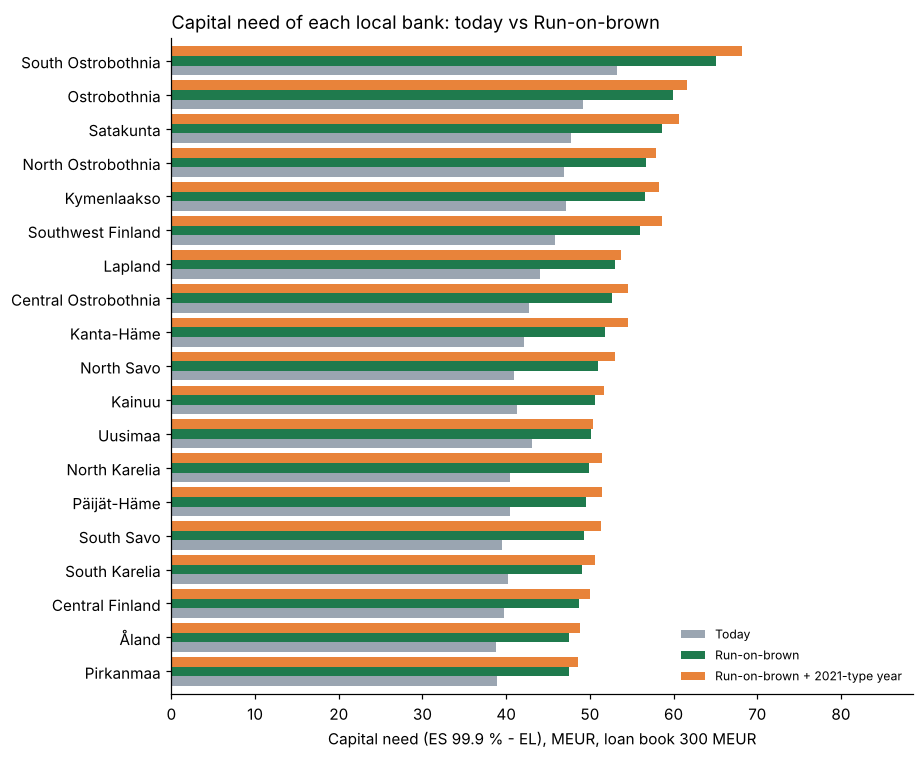

,Jordbruk %,EL idag,EL scenario,Kapital idag,Kapital scenario,Kapital scenario + 2021-år,Kapitalökning %
Landskap,,,,,,,
South Ostrobothnia,59.390,4.390,7.950,53.190,65.120,68.160,22.430
Ostrobothnia,36.020,3.970,6.920,49.180,59.930,61.630,21.870
Satakunta,37.490,3.780,6.530,47.760,58.580,60.660,22.650
North Ostrobothnia,27.980,3.980,6.700,46.940,56.760,57.930,20.910
Kymenlaakso,22.760,3.360,5.470,47.130,56.590,58.300,20.070
Southwest Finland,31.630,3.590,6.020,45.830,55.960,58.590,22.100
Lapland,13.440,3.290,5.190,44.060,52.980,53.670,20.250
Central Ostrobothnia,38.800,4.180,7.180,42.780,52.660,54.520,23.100
Kanta-Häme,33.180,3.490,5.840,42.120,51.760,54.600,22.880


In [11]:
rows = []
for r in m.regions:
    t, s = m.bank_metrics(r, "Today"), m.bank_metrics(r, m.p["main_scenario"])
    v = m.bank_metrics(r, m.p["main_scenario"], "Very bad year")
    rows.append({"Landskap": namn(r), "Jordbruk %": m.shares.loc[r, "Agriculture"] * 100,
                 "EL idag": t["expected_loss_meur"], "EL scenario": s["expected_loss_meur"],
                 "Kapital idag": t["capital_meur"], "Kapital scenario": s["capital_meur"],
                 "Kapital scenario + 2021-år": v["capital_meur"],
                 "Kapitalökning %": (s["capital_meur"] / t["capital_meur"] - 1) * 100})
banks = pd.DataFrame(rows).set_index("Landskap").sort_values("Kapital scenario")
ax = banks[["Kapital idag", "Kapital scenario", "Kapital scenario + 2021-år"]].plot.barh(
    figsize=(8.5, 7), color=[GREY, GREEN, ORANGE], width=0.85)
ax.set_xlabel("Capital need (ES 99.9 % - EL), MEUR, loan book 300 MEUR")
ax.set_title("Capital need of each local bank: today vs Run-on-brown", loc="left")
ax.legend(["Today", "Run-on-brown", "Run-on-brown + 2021-type year"], frameon=False, fontsize=8, loc="lower right")
ax.set_xlim(0, banks["Kapital scenario + 2021-år"].max() * 1.3); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("graf_banker.png", dpi=200); plt.show()
banks.sort_values("Kapital scenario", ascending=False).round(2)

**Tolkning:** Landsbygdsbankerna (Södra Österbotten, Österbotten, Satakunta) har störst kapitalbehov och det växer mest i kronor.
Ett 2021-år lägger till mest där jordbruket är stort och torkan hårdast. Nyland växer minst (+16 %), eftersom jordbruket bara är 3 % av lånen.

## 7. Prissätt ett lån

Exempel: jordbruksföretag, 500 000 €, soliditet 30 %, nettoskuld/EBITDA 4, scenario Run-on-brown, normalt år.

In [12]:
ex = dict(sector="Agriculture", amount_eur=500_000, equity_ratio=0.30, net_debt_ebitda=4.0)
rows = []
for reg in [LAND, "MK15 Ostrobothnia", "MK02 Southwest Finland", "MK06 Pirkanmaa", STAD]:
    r = m.price_loan(reg, **ex)
    rows.append({"Landskap": namn(reg), "Euribor %": r["euribor"] * 100, "Marginal %": r["bank_margin"] * 100,
                 "Egen risk %": r["climate_addon_own_risk"] * 100, "Kapital %": r["climate_addon_concentration"] * 100,
                 "Klimatpåslag %": r["climate_addon"] * 100, "Total ränta %": r["total_rate"] * 100,
                 "PD idag %": r["pd_today"] * 100, "PD scenario %": r["pd_scenario"] * 100})
pd.DataFrame(rows).set_index("Landskap").round(2)

,Euribor %,Marginal %,Egen risk %,Kapital %,Klimatpåslag %,Total ränta %,PD idag %,PD scenario %
Landskap,,,,,,,,
South Ostrobothnia,3.250,2.000,1.680,0.490,2.170,7.420,3.950,7.670
Ostrobothnia,3.250,2.000,1.790,0.480,2.280,7.520,4.330,8.320
Southwest Finland,3.250,2.000,1.530,0.520,2.050,7.290,3.480,6.870
Pirkanmaa,3.250,2.000,1.460,0.520,1.980,7.220,3.280,6.530
Uusimaa,3.250,2.000,1.500,0.520,2.020,7.270,3.390,6.730


### Bra år och dåligt år

Samma lån, men vädret ett visst år följer analogiåret. Detta är ett **stresstest** (vad händer om nästa år blir som 2018?),
inte det pris banken tar i ett normalt läge.

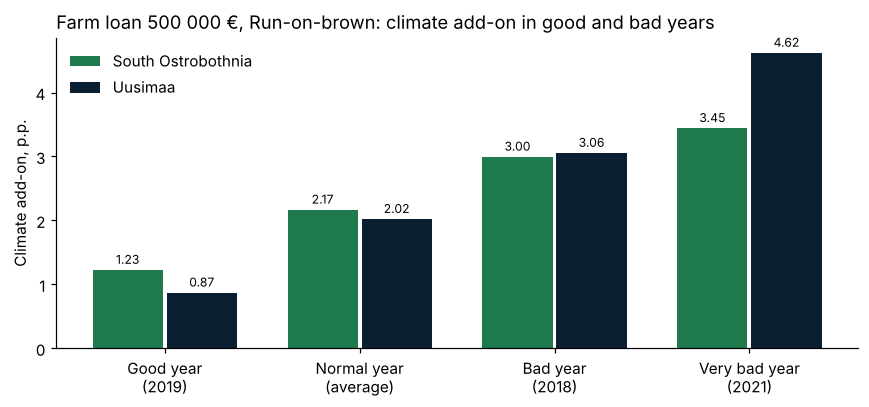

,South Ostrobothnia,Uusimaa
Good year,1.230,0.870
Normal year,2.170,2.020
Bad year,3.000,3.060
Very bad year,3.450,4.620


In [13]:
wl = list(m.p["weather_years"])
vals = {namn(reg): [m.price_loan(reg, weather=w, **ex)["climate_addon_raw"] * 100 for w in wl] for reg in [LAND, STAD]}
x = np.arange(len(wl))
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, (k, v) in enumerate(vals.items()):
    b = ax.bar(x + (i - 0.5) * 0.38, v, 0.36, color=[GREEN, NAVY][i], label=k)
    ax.bar_label(b, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x, [f"{w}\n({m.p['weather_years'][w] or 'average'})" for w in wl])
ax.set_ylabel("Climate add-on, p.p.")
ax.set_title("Farm loan 500 000 €, Run-on-brown: climate add-on in good and bad years", loc="left")
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("graf_bra_daligt_ar.png", dpi=200); plt.show()
pd.DataFrame(vals, index=wl).round(2)

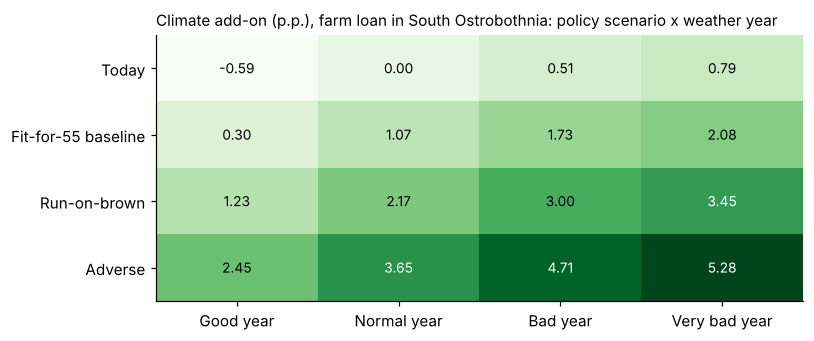

In [14]:
mat = pd.DataFrame({w: {s: m.price_loan(LAND, scenario=s, weather=w, **ex)["climate_addon_raw"] * 100
                        for s in m.p["scenarios"]} for w in wl})
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.imshow(mat.values, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(wl)), wl)
ax.set_yticks(range(len(mat.index)), mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > mat.values.max() * 0.6 else "black")
ax.set_title(f"Climate add-on (p.p.), farm loan in {namn(LAND)}: policy scenario x weather year", loc="left", fontsize=10)
plt.tight_layout(); plt.savefig("graf_matris.png", dpi=200); plt.show()

### Bransch och företagets nyckeltal

Samma bank (Södra Österbotten), olika bransch och företag. Soliditet > 40 % och nettoskuld/EBITDA < 3 = starkt.

In [15]:
rows = []
for sec in SECTORS:
    for label, kw in [("starkt", dict(equity_ratio=0.5, net_debt_ebitda=2)),
                      ("nöjaktigt", dict(equity_ratio=0.3, net_debt_ebitda=4)),
                      ("svagt", dict(equity_ratio=0.1, net_debt_ebitda=6)),
                      ("betalningsstörning", dict(payment_default=True))]:
        r = m.price_loan(LAND, sec, 500_000, **kw)
        rows.append({"Bransch": sec, "Företag": label, "PD idag %": r["pd_today"] * 100,
                     "PD scenario %": r["pd_scenario"] * 100, "Klimatpåslag %": r["climate_addon"] * 100,
                     "Total ränta %": r["total_rate"] * 100})
pd.DataFrame(rows).set_index(["Bransch", "Företag"]).round(2)

PD idag %  PD scenario %  Klimatpåslag %  \
Bransch      Företag                                                        
Agriculture  starkt                  1.970          4.180           1.570   
             nöjaktigt               3.950          7.670           2.170   
             svagt                   7.890         13.940           3.000   
             betalningsstörning     15.790         25.020           4.110   
Construction starkt                  1.230          2.140           0.780   
             nöjaktigt               2.450          4.050           1.100   
             svagt                   4.910          7.630           1.550   
             betalningsstörning      9.810         14.260           2.180   
Trade        starkt                  1.010          1.320           0.240   
             nöjaktigt               2.020          2.570           0.370   
             svagt                   4.040          5.000           0.570   
             betalningsstörning      8.080          9.710           0.860   

                                 Total ränta %  
Bransch      Företag                            
Agriculture  starkt                      6.820  
             nöjaktigt                   7.420  
             svagt                       8.250  
             betalningsstörning          9.350  
Construction starkt                      6.030  
             nöjaktigt                   6.340  
             svagt                       6.790  
             betalningsstörning          7.420  
Trade        starkt                      5.490  
             nöjaktigt                   5.620  
             svagt                       5.820  
             betalningsstörning          6.100

### Underbransch

Varje underbransch (TOL 3 siffror) får en relativ risk från konkurserna 2019–2024. Små grupper krymps mot branschen
(empirisk Bayes), så en underbransch med 4 konkurser inte får en extrem siffra. Det ersätter riskklasserna i kvantmodell-notebooken,
som sorterade och skattade på samma data och därför överdrev skillnaderna.

In [16]:
t = m.subindustries.sort_values(["sector", "relative_risk"], ascending=[True, False])
t = t[["sector", "code", "name", "bankruptcies_2019_2024", "raw_relative_risk", "relative_risk"]]
t.columns = ["Bransch", "Kod", "Underbransch", "Konkurser 2019–24", "Relativ risk (rå)", "Relativ risk (krympt)"]
t.set_index(["Bransch", "Kod"]).round(2)

Underbransch  \
Bransch      Kod                                                              
Agriculture  014                                          Animal production   
             016                          Support activities to agriculture   
             013                                          Plant propagation   
             017                     Hunting, trapping and related services   
             012                                 Growing of perennial crops   
             011                             Growing of non-perennial crops   
             015                                              Mixed farming   
Construction 412  Construction of residential and non-residential buildings   
             429           Construction of other civil engineering projects   
             439                             Other specialised construction   
             411                           Development of building projects   
             421                         Construction of roads and railways   
             432                Electrical, plumbing and other installation   
             422                           Construction of utility projects   
             431                            Demolition and site preparation   
             433                          Building completion and finishing   
Trade        473             Retail sale of automotive fuel (fuel stations)   
             472                  Retail sale of food in specialised stores   
             451                                     Sale of motor vehicles   
             469                                  Non-specialised wholesale   
             463                   Wholesale of food, beverages and tobacco   
             453                                Sale of motor vehicle parts   
             471                      Retail sale in non-specialised stores   
             467                                Other specialised wholesale   
             475                   Retail sale of other household equipment   
             452                   Maintenance and repair of motor vehicles   
             462   Wholesale of agricultural raw materials and live animals   
             454                             Sale and repair of motorcycles   
             476               Retail sale of cultural and recreation goods   
             477           Retail sale of other goods in specialised stores   
             464                               Wholesale of household goods   
             466                 Wholesale of other machinery and equipment   
             474                               Retail sale of ICT equipment   
             465                                 Wholesale of ICT equipment   
             461                       Wholesale on a fee or contract basis   
             478                         Retail sale via stalls and markets   
             479              Retail trade not in stores (incl. e-commerce)   

                  Konkurser 2019–24  Relativ risk (rå)  Relativ risk (krympt)  
Bransch      Kod                                                               
Agriculture  014                158              2.260                  2.240  
             016                 32              2.610                  2.210  
             013                  4              7.900                  1.680  
             017                  1              3.920                  1.180  
             012                  4              0.470                  0.680  
             011                 76              0.480                  0.510  
             015                 18              0.410                  0.490  
Construction 412               1810              1.240                  1.240  
             429                134              1.240                  1.200  
             439                394              1.140                  1.130  
             411     

In [17]:
rows = []
for code_, label in [(None, "Bygg, ej angiven"), ("412", "412 Husbyggande"), ("432", "432 El och VVS"), ("433", "433 Slutbehandling")]:
    r = m.price_loan(STAD, "Construction", 1_000_000, sub_industry=code_)
    rows.append({"Byggföretag i Nyland, 1 M€": label, "Riskfaktor": r["sub_industry_multiplier"],
                 "PD idag %": r["pd_today"] * 100, "PD scenario %": r["pd_scenario"] * 100,
                 "Klimatpåslag %": r["climate_addon"] * 100})
pd.DataFrame(rows).set_index("Byggföretag i Nyland, 1 M€").round(2)

,Riskfaktor,PD idag %,PD scenario %,Klimatpåslag %
"Byggföretag i Nyland, 1 M€",,,,
"Bygg, ej angiven",1.000,3.760,5.990,1.360
412 Husbyggande,1.240,4.660,7.280,1.510
432 El och VVS,0.820,3.090,5.010,1.230
433 Slutbehandling,0.640,2.410,3.990,1.090


## 8. Lånekalkylatorn: marginal, löptid och betalningsplan

Marginalen är nu en egen inställning (i appen ett reglage). Betalningsplanen räknas med samma ränta hela löptiden.

In [18]:
rows = []
for margin in [0.010, 0.015, 0.020, 0.025, 0.030]:
    r = m.price_loan(LAND, bank_margin=margin, **ex)
    p = payment_plan(500_000, r["total_rate"], 10, "annuity")
    rows.append({"Marginal %": margin * 100, "Total ränta %": r["total_rate"] * 100,
                 "Månadsbetalning €": p["first_payment"], "Räntor totalt €": p["total_interest"]})
pd.DataFrame(rows).set_index("Marginal %").round(2)

,Total ränta %,Månadsbetalning €,Räntor totalt €
Marginal %,,,
1.000,6.420,"5,656.060","178,727.540"
1.500,6.920,"5,783.810","194,057.380"
2.000,7.420,"5,913.200","209,584.190"
2.500,7.920,"6,044.220","225,306.470"
3.000,8.420,"6,176.860","241,222.640"


Ränta 7.42 %  ->  5 913 € per månad (utan klimatpåslag 5 364 €)
Klimatpåslaget kostar 65 923 € på 10 år


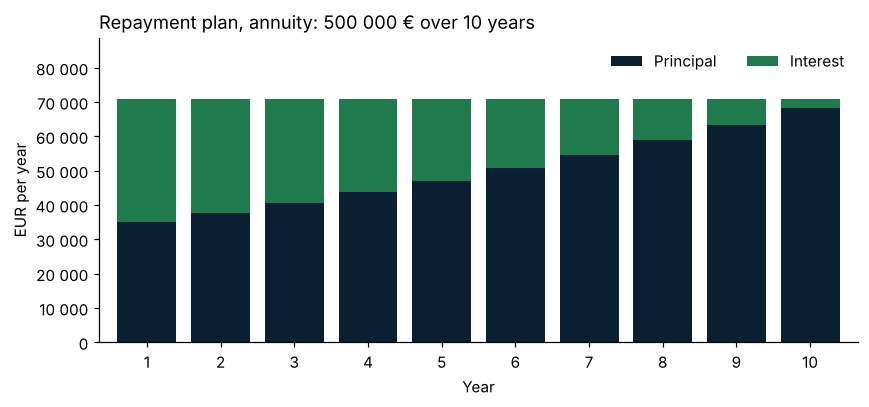

,payments,interest,principal,balance_end
year,,,,
1,70958,35905,35054,464946
2,70958,33215,37744,427203
3,70958,30319,40640,386563
4,70958,27200,43758,342805
5,70958,23842,47116,295689
6,70958,20227,50731,244957
7,70958,16334,54624,190333
8,70958,12143,58816,131517
9,70958,7630,63329,68188


In [19]:
r = m.price_loan(LAND, **ex)
with_c = payment_plan(500_000, r["total_rate"], 10, "annuity")
without_c = payment_plan(500_000, r["total_rate"] - r["climate_addon"], 10, "annuity")
eur = lambda x: f"{x:,.0f}".replace(",", " ")
print(f"Ränta {r['total_rate']*100:.2f} %  ->  {eur(with_c['first_payment'])} € per månad "
      f"(utan klimatpåslag {eur(without_c['first_payment'])} €)")
print(f"Klimatpåslaget kostar {eur(with_c['total_interest'] - without_c['total_interest'])} € på 10 år")
y = pd.DataFrame(with_c["yearly"]).set_index("year")
ax = y[["principal", "interest"]].plot.bar(stacked=True, figsize=(8, 3.8), color=[NAVY, GREEN], width=0.8, rot=0)
ax.set_xlabel("Year"); ax.set_ylabel("EUR per year")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: eur(v)))
ax.set_ylim(0, y["payments"].max() * 1.25)
ax.set_title("Repayment plan, annuity: 500 000 € over 10 years", loc="left")
ax.legend(["Principal", "Interest"], frameon=False, ncol=2, loc="upper right")
plt.tight_layout(); plt.savefig("graf_betalningsplan.png", dpi=200); plt.show()
y.round(0).astype(int)

## 9. Ändra ett antagande

Skicka in en ändring (`overrides`), så räknas allt om. Samma sak gör reglagen i appen. Här: hur känsliga är svaren?

In [20]:
tests = {"Standard": {},
         "Svagare väderlänk (beta 1)": {"weather_beta": 1.0},
         "Starkare väderlänk (beta 2)": {"weather_beta": 2.0},
         "Samma omställning för alla branscher": {"transition_sector_tilt": 0.0},
         "Fullt energikrismönster": {"transition_sector_tilt": 1.0},
         "Jordbruks-PD 5 %": {"pd_agriculture_national": 0.05},
         "Inga regionala torkskillnader": {"drought_regional_weight": 0.0}}
rows = []
for name, ov in tests.items():
    mm = Model(load_params(overrides=ov))
    row = {"Antagande": name}
    for reg in [LAND, STAD]:
        row[f"{namn(reg)}, normalt år %"] = mm.price_loan(reg, **ex)["climate_addon"] * 100
        row[f"{namn(reg)}, 2021-år %"] = mm.price_loan(reg, weather="Very bad year", **ex)["climate_addon"] * 100
    rows.append(row)
pd.DataFrame(rows).set_index("Antagande").round(2)

,"South Ostrobothnia, normalt år %","South Ostrobothnia, 2021-år %","Uusimaa, normalt år %","Uusimaa, 2021-år %"
Antagande,,,,
Standard,2.170,3.450,2.020,4.620
Svagare väderlänk (beta 1),2.170,2.990,2.020,3.630
Starkare väderlänk (beta 2),2.170,3.930,2.020,5.780
Samma omställning för alla branscher,1.250,2.320,1.160,3.320
Fullt energikrismönster,3.040,4.510,2.830,5.870
Jordbruks-PD 5 %,2.810,4.490,2.610,6.060
Inga regionala torkskillnader,2.170,3.440,2.020,4.650


## 10. Kvantmodellen

Eftersom varje bransch har många små lån bestäms bankens förlust helt av ekonomi- och klimatläget. Kretsen behöver därför bara:
- 4 qubits för ekonomin och 4 för klimatet (16 × 16 = 256 lägen)
- 1 qubit som markerar "stor förlust" (minst 10 % av lånestocken), eller som kodar in förlusten för förväntad förlust

**Quantum Amplitude Estimation (QAE)** skattar sannolikheten med kvadratiskt färre anrop än Monte Carlo. Raden
"Monte Carlo samples for same precision" visar hur många simuleringar en klassisk dator skulle behöva för samma precision.

In [21]:
%run kvant_v6.py

Done: Rural bank (South Ostrobothnia) - Today - Normal year


Done: Rural bank (South Ostrobothnia) - Run-on-brown - Normal year


Done: City bank (Uusimaa) - Today - Normal year


Done: City bank (Uusimaa) - Run-on-brown - Normal year

                                                                         0                                1                    2                    3
Bank                                       Rural bank (South Ostrobothnia)  Rural bank (South Ostrobothnia)  City bank (Uusimaa)  City bank (Uusimaa)
Scenario                                                             Today                     Run-on-brown                Today         Run-on-brown
Weather                                                        Normal year                      Normal year          Normal year          Normal year
Qubits                                                                   9                                9                    9                    9
Large loss threshold (MEUR)                                         30.000                           30.000               30.000               30.000
P(large loss) exact %                       

Samma beräkning i ett **2021-år** (mycket dåligt skördeår):

In [22]:
from kvant_v6 import run
quantum_weather = run(scenarios=[m.p["main_scenario"]], model=m, weather="Very bad year")
quantum_weather.T

Done: Rural bank (South Ostrobothnia) - Run-on-brown - Very bad year


Done: City bank (Uusimaa) - Run-on-brown - Very bad year


,0,1
Bank,Rural bank (South Ostrobothnia),City bank (Uusimaa)
Scenario,Run-on-brown,Run-on-brown
Weather,Very bad year,Very bad year
Qubits,9,9
Large loss threshold (MEUR),30.000,30.000
P(large loss) exact %,5.821,1.243
P(large loss) QAE %,5.786,1.242
"P(large loss), fine classical grid %",5.776,1.265
Expected loss exact (MEUR),9.880,5.960
Expected loss QAE (MEUR),9.890,5.900


## 11. Riktig kvanthårdvara (IQM / IBM)

Full QAE kräver tusentals 2-qubitgrindar, vilket dagens maskiner inte klarar utan att bruset tar över. På hårdvaran kör vi
därför osäkerhetsmodellen: 2 + 2 qubits för ekonomi och klimat (16 lägen) och 1 qubit där sannolikheten för 1 är förväntad
förlust delat med maxförlusten. Utan inloggning körs en brusfri simulator och IQM:s brusiga modell (om `iqm-client` är installerat).

In [23]:
%run kvant_hardware.py

 Backend                            Bank     Scenario  Expected loss exact (MEUR)  Measured, raw (MEUR)  Measured, readout-corrected (MEUR)  Two-qubit gates
   ideal Rural bank (South Ostrobothnia)        Today                       4.290                 4.250                               4.250               18
   ideal Rural bank (South Ostrobothnia) Run-on-brown                       7.830                 7.650                               7.650               18
   ideal             City bank (Uusimaa)        Today                       3.910                 3.870                               3.870               18
   ideal             City bank (Uusimaa) Run-on-brown                       5.660                 5.990                               5.990               18
iqm-fake Rural bank (South Ostrobothnia)        Today                       4.290                12.050                              10.820               24
iqm-fake Rural bank (South Ostrobothnia) Run-on-brown     

## 12. Robusthet och begränsningar

### Korrelation med ekonomin (ρ)
Hur mycket svänger Finlands konkurser med konjunkturen? Översatt med Vasicek-modellen ger finsk data bara ρ ≈ 0,01.
Basel-reglerna använder 0,12–0,24 för företag, och bankens kapital räknas med dem, så modellen använder 0,15.
Den finska siffran är låg bland annat för att konkursstatistiken mäter alla företag, även de minsta utan banklån.

In [24]:
from scipy.stats import norm
from scipy.optimize import brentq
tot = pd.read_csv("konkurser_1986_2025.csv", index_col=0)["konkurser_totalt"]
k = pd.read_csv("konkurser_bransch_2003_2025.csv", index_col=0)
f = pd.read_csv("foretag_13w3.csv", index_col=0)
p_avg = k.loc[2018:2024, "totalt"].sum() / f.loc[2018:2024, "totalt"].sum()
zq = np.linspace(-6, 6, 2001); wq = norm.pdf(zq); wq /= wq.sum()

def vasicek_sd(p, rho):
    lp = np.log(norm.cdf((norm.ppf(p) - np.sqrt(rho) * zq) / np.sqrt(1 - rho)))
    mu = (lp * wq).sum()
    return np.sqrt(((lp - mu) ** 2 * wq).sum())

y = np.log(tot)
res = {}
for name, trend in [("linjär trend", np.polyval(np.polyfit(y.index, y.values, 1), y.index)),
                    ("ingen trend", np.full(len(y), y.mean()))]:
    sd = np.sqrt(max((y - trend).var() - (1 / tot).mean(), 1e-6))     # minus slumpbruset i antalet konkurser
    res[name] = {"Svängning (std, log)": sd, "ρ från finsk data": brentq(lambda r: vasicek_sd(p_avg, r) - sd, 1e-5, 0.5)}
print(f"Konkursfrekvens alla företag 2018–24: {p_avg*100:.2f} %   (kvantmodell-notebooken: lowess-trend -> ρ = 0,0075)")
pd.DataFrame(res).T.round(4)

Konkursfrekvens alla företag 2018–24: 0.49 %   (kvantmodell-notebooken: lowess-trend -> ρ = 0,0075)


,"Svängning (std, log)",ρ från finsk data
linjär trend,0.280,0.009
ingen trend,0.305,0.011


### Skördeår och gårdskonkurser
Hur stark är länken mellan dåliga skördar och gårdskonkurser i datan?

In [25]:
s = pd.read_csv("skord_eurostat.csv"); s = s[s.region == "FI"].set_index("ar")
ly = np.log(s.produktion_1000t / s.areal_1000ha)
dev = ly - np.polyval(np.polyfit(ly.index, ly.values, 1), ly.index)
d = pd.DataFrame({"farm": np.log(k["01_jordbruk"]), "total": np.log(k["totalt"]), "harvest": dev}).dropna()
yr = d.index.to_numpy(dtype=float)
X = np.column_stack([np.ones(len(d)), yr - yr.mean(), d["total"], d["harvest"]])
beta, *_ = np.linalg.lstsq(X, d["farm"].values, rcond=None)
resid = d["farm"].values - X @ beta
se = np.sqrt(np.diag(resid @ resid / (len(d) - X.shape[1]) * np.linalg.inv(X.T @ X)))
print(f"Skörd -> gårdskonkurser (samma år, kontroll för trend och alla konkurser): {beta[3]:.2f}  (t = {beta[3]/se[3]:.1f}, {len(d)} år)")
print(f"2020 -> 2021: gårdskonkurser {k.loc[2020, '01_jordbruk']} -> {k.loc[2021, '01_jordbruk']} "
      f"(+{(k.loc[2021, '01_jordbruk'] / k.loc[2020, '01_jordbruk'] - 1)*100:.0f} %), alla konkurser "
      f"+{(k.loc[2021, 'totalt'] / k.loc[2020, 'totalt'] - 1)*100:.0f} %")

Skörd -> gårdskonkurser (samma år, kontroll för trend och alla konkurser): -0.15  (t = -0.3, 22 år)
2020 -> 2021: gårdskonkurser 36 -> 64 (+78 %), alla konkurser +16 %


**Slutsats:** länken syns tydligt i enskilda år (2021, och gårdarnas inkomstras 2018), men inte statistiskt över alla år.
Gårdskonkurser är få (20–70 per år) och 2020 var konstgjort lågt (tillfälliga konkursregler under coronan).
Därför är väderlänken (beta = 1,5) **illustrativ** och kan ändras i `parametrar.json`.

### Övriga begränsningar
- **PD-nivån** bygger på EU-bankernas snitt. Finska bankers egna PD:n är inte offentliga.
- **Låneportföljerna** är skattningar från företagens skulder i landskapet, inte OP-bankernas faktiska lån.
- **Kapitaldelen av påslaget** blir nästan lika stor i alla banker: ett litet lån påverkar bankens risk ungefär lika mycket överallt.
  Skillnaden mellan banker syns i deras totala kapitalbehov (avsnitt 6) och i landskapets egen risk (PD, torka, översvämning).
- **Omställningens fördelning** mellan branscher bygger på en enda episod (energikrisen), som också hade räntehöjningar.
- **Väderåren** påverkar bara jordbruket. Bara tre branscher ingår.
- **Kvantfördelen** (kvadratiskt färre anrop) gäller framtida felkorrigerade kvantdatorer. Idag kör vi QAE på simulator
  och osäkerhetsmodellen på riktig hårdvara.

## Källor
- ECB/ESAs: *Fit-for-55 climate scenario analysis* (nov 2024): PD 2,4 %, jordbruk 3,5 %, scenarierna.
- Statistikcentralen: 13ff, 13fg, 13fp, 13ww, 13w3, 141b, 13z5, 13x2, 13z9, 13w2, 11ig.
- Eurostat apro_cpnhr: spannmål, areal och skörd per NUTS 2-område.
- Jord- och skogsbruksministeriet 19.12.2024: 18 betydande översvämningsområden 2025–2030; NTM-centralernas förslag.
- Luke: torkan 2018 (företagarinkomsten −40 %), skörden 2021 (minsta sedan 1992). Meteorologiska institutet: sommaren 2021.
- ECB / EMMI: Euribor.